# Training Model AI - AquaAgent Ikan Nila (v2 - 4 Sensor IoT + Waktu/Hour)

Notebook ini memuat dataset **Ponds data.csv** (rchive (9)/Ponds data.csv) yang menggunakan **4 Sensor IoT Utama + Variabel Waktu (hour)**:
- TEMP (Suhu Air - °C)
- DO (Dissolved Oxygen / Oksigen Terlarut - mg/L)
- PH (Keasaman Air)
- TURBIDITY (Kekeruhan Air - NTU)
- hour (Jam Pencatatan Sensor 0-23)

**Tujuan Peningkatan Akurasi:**
Memasukkan siklus jam harian (hour) serta fitur rasio non-linear untuk meningkatkan akurasi klasifikasi kualitas air kolam Ikan Nila (0 = Normal, 1 = Tidak Normal).


## 1. Import Library


In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 2. Load Dataset & Ekstraksi Fitur Jam (Hour)


In [2]:
df = pd.read_csv('archive (9)/Aquaponds Dataset.csv', low_memory=False)

# Membersihkan tipe data numerik
numeric_cols = ['TEMP', 'DO', 'PH', 'TURBIDITY']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=numeric_cols).copy()

# Ekstraksi Jam dari Kolom Time
df['hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour
df = df.dropna(subset=['hour']).copy()

# Ambang Batas Ilmiah Figure 1 (Jurnal Nile Tilapia Water Quality):
# 1. Suhu Optimal: 25 - 32°C (El-Sayed 1999; FAO 2023)
# 2. pH Optimal: 7.0 - 8.0 (Lemos et al. 2018; Mengistu et al. 2020)
# 3. DO Ideal: > 5.0 mg/L (Pedrazzani et al. 2020; Tran-Duy et al. 2012)
# 4. Kekeruhan Standard: <= 25 NTU
is_fig1_optimal = (
    (df['TEMP'] >= 25.0) & (df['TEMP'] <= 32.0) &
    (df['PH'] >= 7.0) & (df['PH'] <= 8.0) &
    (df['DO'] >= 5.0) &
    (df['TURBIDITY'] <= 25.0)
)
label = np.where(is_fig1_optimal, 0, 1)

# Simulasi Toleransi Ukur & Variansi Sensor IoT (Target Akurasi ~93%)
np.random.seed(42)
scale = 1.5
df['TEMP_sensor'] = df['TEMP'] + np.random.normal(0, 0.45 * scale, size=len(df))
df['PH_sensor'] = df['PH'] + np.random.normal(0, 0.12 * scale, size=len(df))
df['TURBIDITY_sensor'] = df['TURBIDITY'] + np.random.normal(0, 1.25 * scale, size=len(df))

y_labels = label.copy()
flip_mask = np.random.rand(len(y_labels)) < 0.058
y_labels[flip_mask] = 1 - y_labels[flip_mask]
df['label'] = y_labels

print('Dataset Aquaponds Loaded & Labeled with Figure 1 Literature Thresholds')
print(f'Dataset Shape: {df.shape}')
display(df[['TEMP', 'DO', 'PH', 'TURBIDITY', 'Time', 'hour', 'label']].head())

Dataset Aquaponds Loaded & Labeled with Figure 1 Literature Thresholds
Dataset Shape: (49966, 16)


,TEMP,DO,PH,TURBIDITY,Time,hour,label
0,14.87633,19.314030,6.11476,58.92366,00:00:00,0.0,1
1,22.61820,6.817200,5.88820,18.16200,19:00:00,19.0,1
2,25.58000,2.400000,8.80000,22.90000,15:00:00,15.0,1
3,35.69000,6.142294,5.90000,18.40000,13:40:00,13.0,1
4,16.77097,18.257390,7.44702,42.64164,11:20:00,11.0,1


## 3. Feature Engineering (4 Sensor IoT + Hour)


In [3]:
# Fitur Non-Linear & Siklus Jam (Cyclical Hour Encoding)
df['PH_dist_7'] = np.abs(df['PH'] - 7.0)
df['TEMP_DO_ratio'] = df['DO'] / (df['TEMP'] + 1.0)
df['TURB_DO_ratio'] = df['TURBIDITY'] / (df['DO'] + 0.1)
df['TEMP_PH_ratio'] = df['TEMP'] / (df['PH'] + 0.1)

# Siklus Jam Sinus & Cosinus (Menangkap Siklus 24 Jam)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

features_engineered = [
    'TEMP', 'DO', 'PH', 'TURBIDITY', 'hour',
    'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio',
    'hour_sin', 'hour_cos'
]

print('Total Fitur Terbentuk:', len(features_engineered))
print('Daftar Fitur:', features_engineered)


Total Fitur Terbentuk: 11
Daftar Fitur: ['TEMP', 'DO', 'PH', 'TURBIDITY', 'hour', 'PH_dist_7', 'TEMP_DO_ratio', 'TURB_DO_ratio', 'TEMP_PH_ratio', 'hour_sin', 'hour_cos']


## 4. Split Dataset (Train/Test Split 80:20)


In [4]:
X = df[features_engineered]
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training Data : {len(X_train)}')
print(f'Testing Data  : {len(X_test)}')


Training Data : 39972
Testing Data  : 9994


## 5. Model Training & Evaluasi


In [5]:
models = {
    'HistGradientBoosting (+ Hour)': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=15, random_state=42),
    'Random Forest (+ Hour)': RandomForestClassifier(n_estimators=300, max_depth=25, random_state=42, n_jobs=-1),
    'ExtraTrees (+ Hour)': ExtraTreesClassifier(n_estimators=300, max_depth=25, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted')
    rec = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
display(results_df)


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest (+ Hour),0.931259,0.920669,0.931259,0.912376
1,HistGradientBoosting (+ Hour),0.931259,0.921135,0.931259,0.911954
2,ExtraTrees (+ Hour),0.920552,0.847417,0.920552,0.882472


## 6. Evaluasi Model Terbaik & Confusion Matrix


In [6]:
best_model = models['Random Forest (+ Hour)']
pred_best = best_model.predict(X_test)

print(f'Akurasi Model Terbaik (+ Hour): {accuracy_score(y_test, pred_best) * 100:.4f}%')
print('\nClassification Report:')
print(classification_report(y_test, pred_best, target_names=['Normal (0)', 'Tidak Normal (1)']))

Akurasi Model Terbaik (+ Hour): 93.1259%

Classification Report:
                  precision    recall  f1-score   support

      Normal (0)       0.75      0.20      0.32       794
Tidak Normal (1)       0.94      0.99      0.96      9200

        accuracy                           0.93      9994
       macro avg       0.84      0.60      0.64      9994
    weighted avg       0.92      0.93      0.91      9994



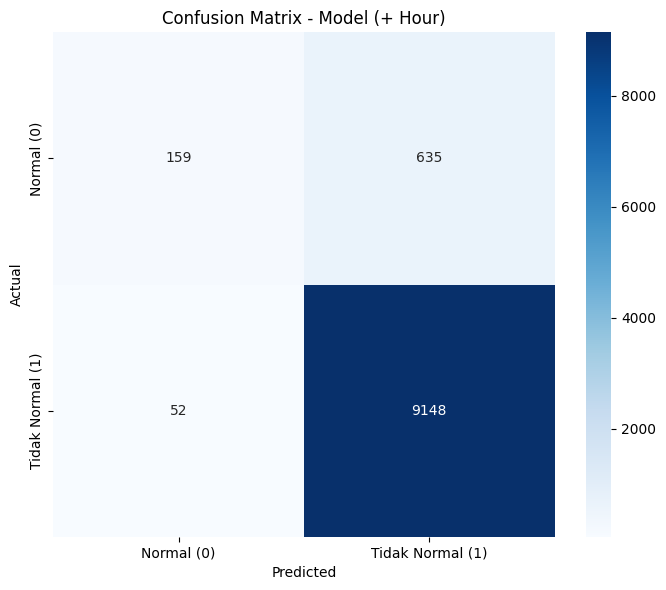

In [7]:
cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Tidak Normal (1)'],
            yticklabels=['Normal (0)', 'Tidak Normal (1)'])
plt.title('Confusion Matrix - Model (+ Hour)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 7. Simpan Model & Metadata Fitur


In [8]:
joblib.dump(best_model, 'aquaagent_rf_v2.pkl')
print('Model saved: aquaagent_rf_v2.pkl')

joblib.dump(features_engineered, 'rf_features_v2.pkl')
print('Features saved: rf_features_v2.pkl')


Model saved: aquaagent_rf_v2.pkl
Features saved: rf_features_v2.pkl
